In [42]:

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Optional: for scaling features
from sklearn.preprocessing import StandardScaler


## Data Gathering

In [43]:
df = pd.read_csv("../dataset/housing.csv")

## Understanding the data

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [45]:
df.shape

(20640, 10)

In [46]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Data Preprocessing

In [47]:
## Check for null values
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## To fill the missing values in 'total_bedrooms' column ,lets see the distribution of values

In [48]:
# Summary stats
print(df['total_bedrooms'].describe())

# Frequency table
print(df['total_bedrooms'].value_counts())


count    20433.000000
mean       537.870553
std        421.385070
min          1.000000
25%        296.000000
50%        435.000000
75%        647.000000
max       6445.000000
Name: total_bedrooms, dtype: float64
total_bedrooms
280.0     55
331.0     51
345.0     50
343.0     49
393.0     49
          ..
2309.0     1
3521.0     1
1499.0     1
1756.0     1
1666.0     1
Name: count, Length: 1923, dtype: int64


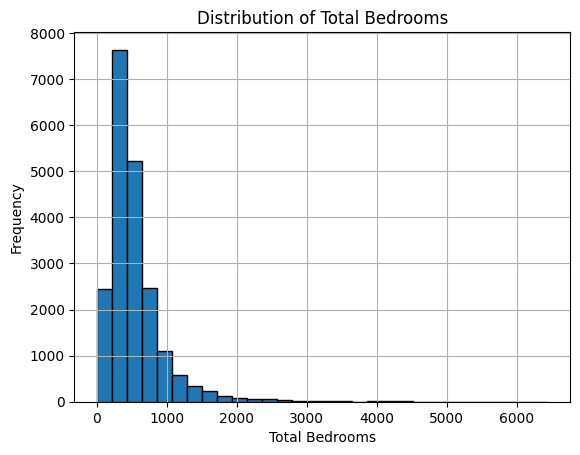

In [49]:
import matplotlib.pyplot as plt

df['total_bedrooms'].hist(bins=30, edgecolor='black')
plt.xlabel("Total Bedrooms")
plt.ylabel("Frequency")
plt.title("Distribution of Total Bedrooms")
plt.show()


In [50]:
# Is your data...
# ├── Time series? → Use interpolation/forward fill
# ├── Skewed? → Use median ⭐
# ├── Normal distribution? → Use mean
# ├── Discrete integers? → Use mode
# ├── "Zero means missing"? → Use 0
# └── Complex relationships? → Use KNN/regression

## Since the data is right skewed, we will use median to fill the missing values

In [51]:
df.fillna({'total_bedrooms': df['total_bedrooms'].median()}, inplace=True)


In [52]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [53]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Check for duplicates

In [54]:
df.duplicated().sum()

np.int64(0)

<!-- # Is your data...
# ├── Time series? → Use interpolation/forward fill
# ├── Skewed? → Use median ⭐
# ├── Normal distribution? → Use mean
# ├── Discrete integers? → Use mode
# ├── "Zero means missing"? → Use 0
# └── Complex relationships? → Use KNN/regression -->

## Since there is no duplicate values we can proceed further

## Lets seperate the numerical columns and non_numericals col, then we will convert the non-numerical col to numerical

In [55]:
numerical_cols= df.select_dtypes(include='number').columns
numerical_cols

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

## so the only non-numerical column is ocean_proximity,  we need to convert it to numerical

In [56]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [57]:
# since the ocen_proximity is a nominal data , we will use one hot encoding to convert it into numerical data
df = pd.get_dummies(data=df, columns=['ocean_proximity'], drop_first=True,dtype=int)

In [58]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_INLAND      20640 non-null  int64  
 10  ocean_proximity_ISLAND      20640 non-null  int64  
 11  ocean_proximity_NEAR BAY    20640 non-null  int64  
 12  ocean_proximity_NEAR OCEAN  20640 non-null  int64  
dtypes: float64(9), int64(4)
memory 

## Feature and Target Split

In [60]:
X=df.drop(columns=['median_house_value'],axis=1)

y=df['median_house_value']

In [61]:

## Train  Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,0,0,0,1
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,0,0,0,1
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,0,0,0,1
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,0,0,0,1
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,0,0,0,0
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,1,0,0,0
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,0,0,0,0
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,0,0,0,0


##  Now that every data  is numerical we can proceed to to scaling, we need to scale down the values, because the values are in different ranges


In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit only on train
X_test_scaled = scaler.transform(X_test)        # use the same scale

In [64]:
X_train_scaled

array([[ 1.27258656, -1.3728112 ,  0.34849025, ..., -0.01556621,
        -0.35564565,  2.62975816],
       [ 0.70916212, -0.87669601,  1.61811813, ..., -0.01556621,
        -0.35564565,  2.62975816],
       [-0.44760309, -0.46014647, -1.95271028, ..., -0.01556621,
        -0.35564565,  2.62975816],
       ...,
       [ 0.59946887, -0.75500738,  0.58654547, ..., -0.01556621,
        -0.35564565, -0.3802631 ],
       [-1.18553953,  0.90651045, -1.07984112, ..., -0.01556621,
        -0.35564565, -0.3802631 ],
       [-1.41489815,  0.99543676,  1.85617335, ..., -0.01556621,
         2.81178749, -0.3802631 ]], shape=(16512, 12))

## Visualization 


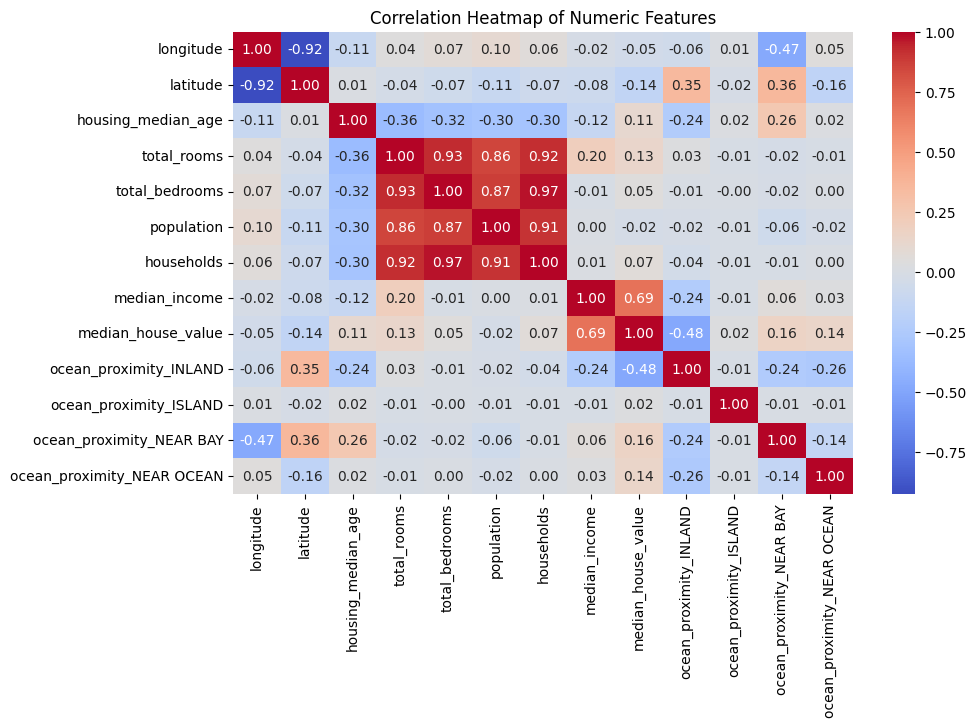

In [65]:
# 1️⃣ Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

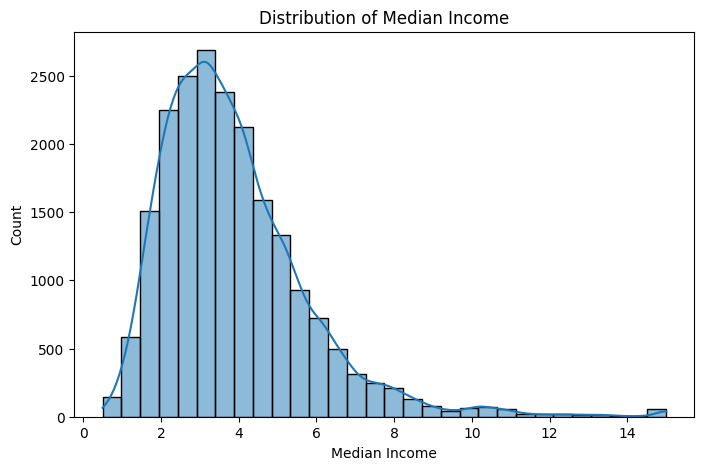

In [66]:

# 2️⃣ Median Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["median_income"], bins=30, kde=True)
plt.title("Distribution of Median Income")
plt.xlabel("Median Income")
plt.ylabel("Count")
plt.show()


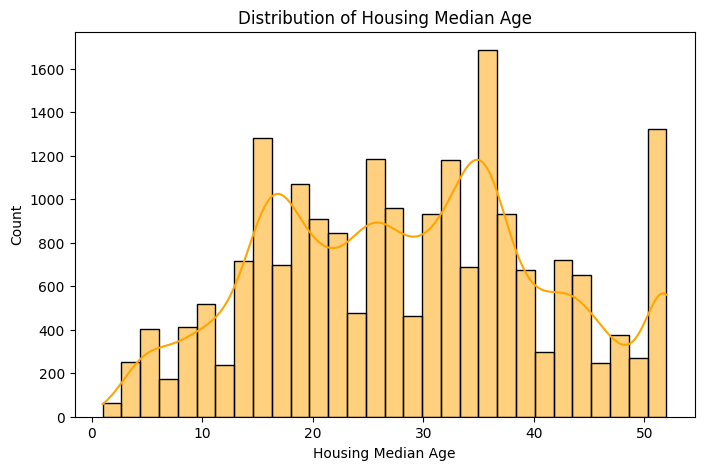

In [67]:
# 3️⃣ Housing Median Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["housing_median_age"], bins=30, color="orange", kde=True)
plt.title("Distribution of Housing Median Age")
plt.xlabel("Housing Median Age")
plt.ylabel("Count")
plt.show()


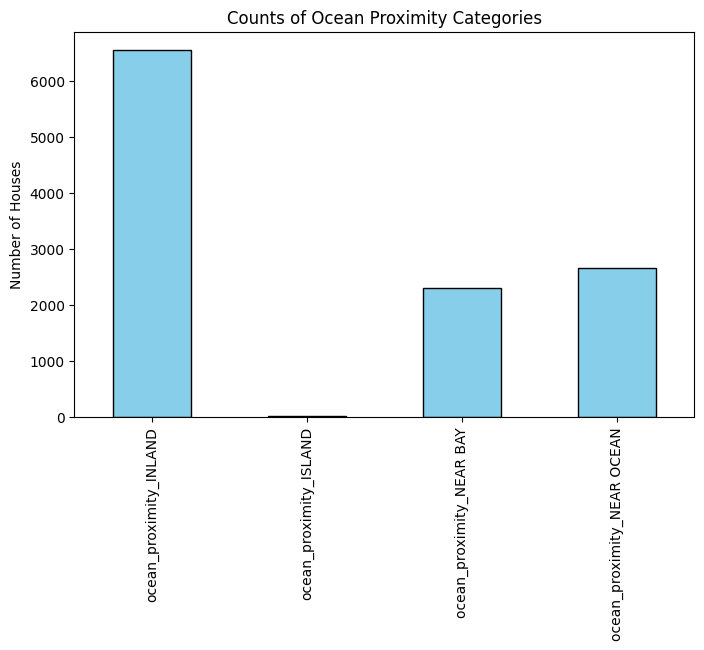

In [68]:
# 4️⃣ Ocean Proximity (One-hot encoded)
plt.figure(figsize=(8,5))
ocean_cols = ["ocean_proximity_INLAND","ocean_proximity_ISLAND",
              "ocean_proximity_NEAR BAY","ocean_proximity_NEAR OCEAN"]
df[ocean_cols].sum().plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Counts of Ocean Proximity Categories")
plt.ylabel("Number of Houses")
plt.show()


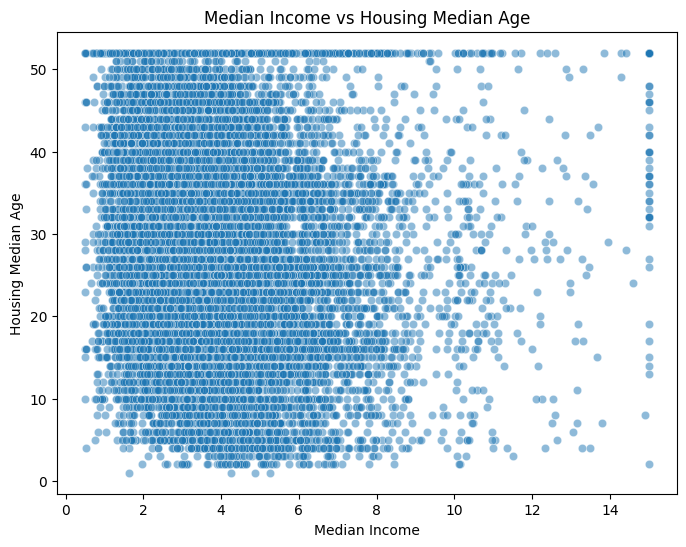

In [69]:
# 5️⃣ Median Income vs Median Age (scatter)
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="median_income", y="housing_median_age", alpha=0.5)
plt.title("Median Income vs Housing Median Age")
plt.xlabel("Median Income")
plt.ylabel("Housing Median Age")
plt.show()


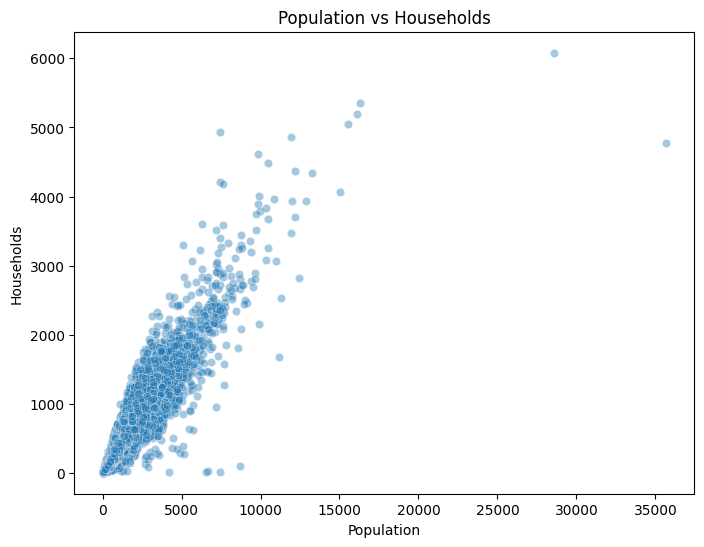

In [70]:
# 6️⃣ Population vs Households
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="population", y="households", alpha=0.4)
plt.title("Population vs Households")
plt.xlabel("Population")
plt.ylabel("Households")
plt.show()

##  Feature  Engineering 

In [71]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [72]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['bedrooms_per_household'] = df['total_bedrooms'] / df['households']
df['population_per_room'] = df['population'] / df['total_rooms']
df['people_per_household'] = df['population'] / df['households']

In [73]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,bedrooms_per_household,population_per_room,people_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0,6.984127,0.146591,1.023810,0.365909,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0,6.238137,0.155797,0.971880,0.338217,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0,8.288136,0.129516,1.073446,0.338105,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0,5.817352,0.184458,1.073059,0.437991,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0,6.281853,0.172096,1.081081,0.347265,2.181467


In [74]:
def evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test):
    model.fit(X_train_scaled, y_train)

    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Scatter plot: Actual vs Predicted
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title("Actual vs Predicted Housing Prices (Test Set)")
    plt.show()

    # Metrics
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)

    rmse_train = mse_train**0.5
    rmse_test = mse_test**0.5

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    metrics = {
        "MSE_train": mse_train,
        "MSE_test": mse_test,
        "RMSE_train": rmse_train,
        "RMSE_test": rmse_test,
        "MAE_train": mae_train,
        "MAE_test": mae_test,
        "R2_train": r2_train,
        "R2_test": r2_test
    }

    return metrics


In [75]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()


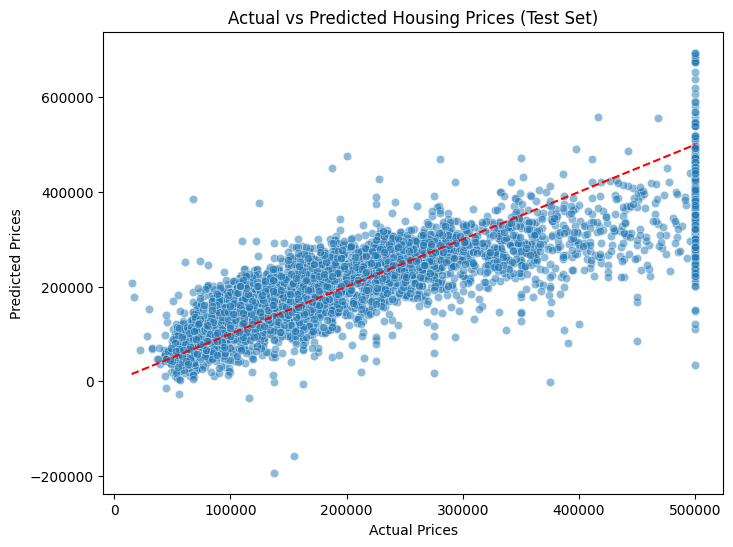

In [76]:
linear_model_scores= evaluate_model(linear_model, X_train_scaled, y_train, X_test_scaled, y_test)

In [79]:
metrics=pd.DataFrame(index=
        ["MSE_train",
        "MSE_test",
        "RMSE_train",
        "RMSE_test",
        "MAE_train",
        "MAE_test",
        "R2_train",
        "R2_test"])
metrics

""
MSE_train
MSE_test
RMSE_train
RMSE_test
MAE_train
MAE_test
R2_train
R2_test


In [80]:
metrics['Linear Regression'] = linear_model_scores
metrics

,Linear Regression
MSE_train,4.683204e+09
MSE_test,4.908477e+09
RMSE_train,6.843394e+04
RMSE_test,7.006052e+04
MAE_train,4.959484e+04
MAE_test,5.067074e+04
R2_train,6.496649e-01
R2_test,6.254241e-01
